# AI-Generated SOAP Notes with MedGemma

This notebook demonstrates how to use **MedGemma**, Google's multimodal medical AI model, to automatically generate clinical SOAP notes from patient records.

## What is a SOAP Note?

SOAP notes are a standard format for clinical documentation:

| Section | Description |
|---------|-------------|
| **S**ubjective | Patient-reported symptoms, complaints, history |
| **O**bjective | Clinical findings: vitals, labs, imaging, exam |
| **A**ssessment | Diagnoses, clinical reasoning, risk factors |
| **P**lan | Treatment, follow-up, preventive care |

## The Challenge

Patients with long medical histories can have **thousands of clinical events**. This exceeds the context window of most LLMs. Our solution:

1. **Hierarchical Summarization**: Break history into time periods, summarize each
2. **Aggregation**: Combine period summaries into a comprehensive SOAP note
3. **Multimodal**: Include imaging (DICOM) when available

## Requirements

```bash
pip install synthlab torch transformers>=4.50.0 accelerate
```

**Note**: MedGemma requires a GPU with at least 16GB VRAM for the 4B model.

In [1]:
%load_ext autoreload
%autoreload 1
%aimport synthlab.soap

import synthlab as sl
from synthlab.soap import SOAPNoteGenerator, generate_soap_note, FHIRFormatter

/home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[01/26/26 11:06:28] INFO     Loading faiss.                                                           ]8;id=779664;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/faiss/loader.py\loader.py]8;;\:]8;id=345084;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/faiss/loader.py#133\133]8;;\

                    INFO     Successfully loaded faiss.                                               ]8;id=240644;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/faiss/loader.py\loader.py]8;;\:]8;id=872008;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/faiss/loader.py#135\135]8;;\


  ░██████╗██╗░░░██╗███╗░░██╗████████╗██╗░░██╗  ██╗░░░░░░█████╗░██████╗░
  ██╔════╝╚██╗░██╔╝████╗░██║╚══██╔══╝██║░░██║  ██║░░░░░██╔══██╗██╔══██╗
  ╚█████╗░░╚████╔╝░██╔██╗██║░░░██║░░░███████║  ██║░░░░░███████║██████╦╝
  ░╚═══██╗░░╚██╔╝░░██║╚████║░░░██║░░░██╔══██║  ██║░░░░░██╔══██║██╔══██╗
  ██████╔╝░░░██║░░░██║░╚███║░░░██║░░░██║░░██║  ███████╗██║░░██║██████╦╝
  ╚═════╝░░░░╚═╝░░░╚═╝░░╚══╝░░░╚═╝░░░╚═╝░░╚═╝  ╚══════╝╚═╝░░╚═╝╚═════╝░
        ▌║█║▌│║▌│║▌║▌█║▌║█║▌│║▌│║▌║▌█║▌║█║▌│║▌│║▌║▌█║▌│║▌│║▌║▌█║
  ════════════════════════════════════════════════════════════════════
  Synthetic Healthcare Data Toolkit
  ────────────────────────────────────────────────────────────────────
  ◈ EHR        Synthetic patient records (diagnoses, meds, labs)
  ◈ Genomics   Synthetic genotypes with realistic LD structure
  ◈ Imaging    Datasets + synthetic generation (CT, MRI, X-ray)
  ◈ Multimodal Linked EHR + Imaging + Genomics per patient
  ◈ AI Notes   SOAP notes with causal graph analysis
  ══════════════════

## 1. Load Patient Data

First, let's load patients from the Coherent Dataset. This dataset includes linked EHR (FHIR), imaging (DICOM), and genomics data.

In [2]:
# Load multimodal patient data
dataset = sl.load_multimodal_dataset(max_patients=10)

# Show summary
dataset.print_summary()

Indexing genomics: 100%|██████████| 889/889 [00:00<00:00, 440748.97file/s]
Indexing notes: 0file [00:00, ?file/s]

✓ Loaded 10 patients



Multimodal Dataset Summary

Total patients: 10

Modality coverage:
  fhir: 10 patients (100.0%)
  dicom: 2 patients (20.0%)
  genomics: 8 patients (80.0%)
  notes: 0 patients (0.0%)

Patients with all modalities: 2
Total DICOM files: 2
Total conditions: 131
Total medications: 1671


In [3]:
# Select a patient with rich clinical history
# Find patient with most conditions
patient = max(dataset, key=lambda p: len(p.get_conditions()))

demographics = patient.get_demographics()
print(f"Selected patient: {demographics['name']}")
print(f"Patient ID: {patient.patient_id}")
print(f"Gender: {demographics['gender']}")
print(f"Birth date: {demographics['birth_date']}")
print()
print(f"Clinical data:")
print(f"  Conditions: {len(patient.get_conditions())}")
print(f"  Medications: {len(patient.get_medications())}")
print(f"  Encounters: {len(patient.get_encounters())}")
print(f"  Observations: {len(patient.get_observations())}")
print(f"  Procedures: {len(patient.get_procedures())}")
print(f"  DICOM images: {len(patient.dicom_paths)}")

Selected patient: Alejandro916 Konopelski743
Patient ID: 967d5226-f8c4-60a8-b882-6ef803af88a6
Gender: male
Birth date: 1930-04-29

Clinical data:
  Conditions: 20
  Medications: 182
  Encounters: 323
  Observations: 2243
  Procedures: 45
  DICOM images: 1


## 2. Preview Patient Data

Let's see what data will be sent to MedGemma. The `FHIRFormatter` converts FHIR bundles into structured text.

In [4]:
# Preview formatted patient data
formatted_data = FHIRFormatter.format_patient_for_llm(patient, max_tokens=10000)

print("Formatted patient data (preview):")
print("=" * 60)
print(formatted_data[:3000])
print("\n... [truncated for display] ...")
print(f"\nTotal characters: {len(formatted_data):,}")
print(f"Estimated tokens: ~{len(formatted_data) // 4:,}")

Formatted patient data (preview):
("## PATIENT DEMOGRAPHICS\nName: Alejandro916 Konopelski743\nGender: male\nDate of Birth: 1930-04-29\nAddress: 318 Russel Bay Apt 77, Charlton, MA, US\n\n## CONDITIONS / DIAGNOSES\n- 2021-03-23: Bullet wound [resolved]\n- 2019-10-19: Acute viral pharyngitis (disorder) [resolved]\n- 2018-08-11: Acute viral pharyngitis (disorder) [resolved]\n- 2017-06-27: Stroke [active]\n- 2015-05-28: Viral sinusitis (disorder) [resolved]\n- 2015-01-15: Viral sinusitis (disorder) [resolved]\n- 2013-08-27: Alzheimer's disease (disorder) [active]\n- 2013-01-11: Viral sinusitis (disorder) [resolved]\n- 2008-05-02: Silent micro-hemorrhage of brain (disorder) [active]\n- 2008-05-02: Numbness of face (finding) [active]\n- 2008-05-02: Abnormal gait (finding) [active]\n- 1998-10-06: Hyperlipidemia [active]\n- 1973-05-15: Hyperglycemia (disorder) [active]\n- 1973-05-15: Prediabetes [active]\n- 1970-09-12: Chronic sinusitis (disorder) [active]\n- 1970-05-05: Neuropathy due to typ

## 3. Understanding Hierarchical Summarization

For patients with long histories, we use a **hierarchical approach**:

```
┌─────────────────────────────────────────────────────────────┐
│                    PATIENT HISTORY                         │
├─────────────┬─────────────┬─────────────┬─────────────────┤
│  2000-2004  │  2005-2009  │  2010-2014  │    2015-2024    │
│  (Chunk 1)  │  (Chunk 2)  │  (Chunk 3)  │    (Chunk 4)    │
└──────┬──────┴──────┬──────┴──────┬──────┴────────┬────────┘
       │             │             │               │
       ▼             ▼             ▼               ▼
   Summary 1     Summary 2     Summary 3       Summary 4
       │             │             │               │
       └─────────────┴─────────────┴───────────────┘
                           │
                           ▼
                 ┌─────────────────┐
                 │   FINAL SOAP    │
                 │      NOTE       │
                 └─────────────────┘
```

This allows us to process decades of patient history while staying within context limits.

In [5]:
# Preview how patient history would be chunked
chunks = FHIRFormatter.chunk_by_time_period(patient, period_years=5)

print(f"Patient history spans {len(chunks)} time periods:")
print("=" * 60)

for start, end, chunk_text in chunks:
    # Count events in chunk
    sl.utils.count_tokens(chunk_text)
    lines = chunk_text.split("\n")
    print(f"\n{start} - {end}:")
    print(f"  Characters: {len(chunk_text):,}")
    print(f"  Preview: {chunk_text}")

Patient history spans 12 time periods:

1964 - 1968:
  Characters: 244
  Preview: ## PERIOD: 1964 - 1968

Conditions diagnosed:
  - Diabetes
  - Anemia (disorder)
  - Hypertriglyceridemia (disorder)
  - Metabolic syndrome X (disorder)

Medications prescribed:
  - Vitamin B 12 5 MG/ML Injectable Solution

Encounters: 3 visits

1969 - 1973:
  Characters: 438
  Preview: ## PERIOD: 1969 - 1973

Conditions diagnosed:
  - Neuropathy due to type 2 diabetes mellitus (disorder)
  - Chronic sinusitis (disorder)
  - Hyperglycemia (disorder)
  - Prediabetes

Medications prescribed:
  - 24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet
  - 24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet
  - 24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet

Encounters: 4 visits

1974 - 1978:
  Characters: 489
  Preview: ## PERIOD: 1974 - 1978

Medications prescribed:
  - 24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet
  - 24 HR Metformin hydrochlor

In [6]:
patient.genomics

INDEX,INDEX_PREFIX,CHROMOSOME,LOCATION,STRAND,ANCESTRAL_ALLELE,VARIANT_ALLELE_LIST,GENE,CLINICAL_SIGNIFICANCE,ALLELE,VARIANT
str,str,i64,i64,i64,str,str,str,str,str,bool
"""rs1126742_FS1""","""rs1126742""",1,46932824,1,"""A""","""G""","""CYP4A11""","""Uncertain""","""A""",false
"""rs1126742_FS2""","""rs1126742""",1,46932824,2,"""A""","""G""","""CYP4A11""","""Uncertain""","""A""",false
"""rs11591147_FS1""","""rs11591147""",1,55039974,1,"""G""","""A, T""","""PCSK9""","""Pathogenic""","""G""",false
"""rs11591147_FS2""","""rs11591147""",1,55039974,2,"""G""","""A, T""","""PCSK9""","""Pathogenic""","""G""",false
"""rs16847548_FS1""","""rs16847548""",1,162065484,1,"""T""","""C""","""Unlisted""","""Uncertain""","""T""",false
…,…,…,…,…,…,…,…,…,…,…
"""rs1041740_FS2""","""rs1041740""",21,31667849,2,"""C""","""T""","""SOD1""","""Uncertain""","""C""",false
"""rs1805127_FS1""","""rs1805127""",21,34449523,1,"""T""","""C""","""KCNE1""","""Benign""","""T""",false
"""rs1805127_FS2""","""rs1805127""",21,34449523,2,"""T""","""C""","""KCNE1""","""Benign""","""T""",false


## 4. Generate SOAP Note

Now let's generate the SOAP note using MedGemma. The generator will:
1. Analyze the patient history length
2. Choose direct or hierarchical approach
3. Optionally include DICOM images
4. Generate structured SOAP output

### Build the SNOMED index

We need to build the SNOMED index before we can use the SOAP note generator. 

This lets us align concepts extracted from the EHR to controlled SNOMED terms (very useful for causal graph construction).

This will download the vocabulary (~29MB) and build a vector database of all SNOMED terms using an embeedding model.

In [7]:
import synthlab as sl                                                                                          
                                                                                                                
# This will auto-download from your private repo and build the index                                           
embedding_model_id = "Qwen/Qwen3-Embedding-0.6B"
linker = sl.load_snomed_linker(model_id=embedding_model_id, 
                                    # force=True
                                    )                                                                               
                                                                                                                
# # Or test just the download:                                                                                     
# sl.download_snomed_vocabulary(force=True)  

Loading SNOMED index: snomed_full_349211_qwen3_0.6b.index (349,211 concepts)
Loading embedding model: Qwen/Qwen3-Embedding-0.6B


[01/26/26 11:06:30] INFO     Load pretrained SentenceTransformer:                        ]8;id=674413;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/sentence_transformers/SentenceTransformer.py\SentenceTransformer.py]8;;\:]8;id=409045;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/sentence_transformers/SentenceTransformer.py#227\227]8;;\
                             Qwen/Qwen3-Embedding-0.6B                                                             

`torch_dtype` is deprecated! Use `dtype` instead!


[01/26/26 11:06:32] INFO     1 prompt is loaded, with the key: query                     ]8;id=433763;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/sentence_transformers/SentenceTransformer.py\SentenceTransformer.py]8;;\:]8;id=842979;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/sentence_transformers/SentenceTransformer.py#378\378]8;;\

  Loaded via sentence-transformers
  Flash Attention 2: enabled
  Device: cuda


In [8]:
out =linker.link("Alzheimer's")
out

[SNOMEDMatch(concept_id='26929004', term="Alzheimer's disease", score=0.9748426675796509, semantic_type='Disorder'),
 SNOMEDMatch(concept_id='52448006', term='Dementia', score=0.9361522197723389, semantic_type='Disorder'),
 SNOMEDMatch(concept_id='15662003', term='Senile dementia', score=0.9019885063171387, semantic_type='Disorder'),
 SNOMEDMatch(concept_id='394877006', term="FH: Alzheimer's disease", score=0.8819950819015503, semantic_type='Context-dependent'),
 SNOMEDMatch(concept_id='160325007', term='FH: Senile dementia', score=0.8712798357009888, semantic_type='Context-dependent')]

In [15]:
# Initialize the SOAP note generator
# Note: This will download MedGemma on first run (~8GB)

generator = SOAPNoteGenerator(
    # ----- Model and Device -------
    model_id="google/medgemma-1.5-4b-it",    # 4B parameter model
    device="auto",                           # Auto-select GPU
    multi_gpu=False,                         # Distribute across all GPUs
    gpu_memory_fraction=0.9,                 # Use 90% of each GPU's memory
    torch_dtype="bfloat16",                  # Memory-efficient dtype

    # ----- Sampling & Output -------
    do_sample=False, # Set to False for deterministic output
    repetition_penalty=1.2,
    # temperature=0.7,
    # top_p=0.9,

    # ----- Chunking / Summarization -------
    chunk_period_years=None,                 # Years per chunk

    # ----- NER & Causal Graph -------
    entity_extraction_model="google/medgemma-1.5-4b-it",
    separate_causal_graph=True,

    # ----- Imaging -------
    include_imaging=True,                    # Include DICOM images if available
    max_images=3,                            # Max images to include

    # ----- Genomics -------
    use_biomcp=True,                         # Use BioMCP to get more info on genetics

    # ----- SNOMED / Grounding -------
    ground_snomed=True,
    grounded_graph_mode=True,
    snomed_embedding_model=embedding_model_id,

    # ----- Misc -------
    verbose=2,                            # Show progress
)

SOAPNoteGenerator initialized:
  Model: google/medgemma-1.5-4b-it
  Device: auto
  Imaging: enabled (max 3 images)
  Chunking: disabled (direct mode only)
  Generation limits:
    max_new_tokens_chunk: 8,192
    max_new_tokens_final: 8,192
  Sampling: do_sample=False, repetition_penalty=1.2
  BioMCP: enabled
  Separate causal graph: enabled
  Causal graph: excluding admissions (default)
  SNOMED grounding: enabled (Qwen/Qwen3-Embedding-0.6B, two-stage mode)


In [16]:
# Generate SOAP note
# This may take ~1-2 min (including images) depending on patient history length 
# To speed up further, ensure torchvision and flash-attn are installed
soap_note = generator.generate(
    patient,
)
soap_note

SOAP: Alejandro Ko:   0%|          | 0/6 [00:00<?, ?it/s, BioMCP: enriching variants]

    [DEBUG] format_patient_for_llm: include_genomics=True, calling _format_genomics
    [DEBUG] _format_genomics called: use_biomcp=True, df_type=<class 'polars.dataframe.frame.DataFrame'>
    [DEBUG] genomics_df has 322 rows
    [DEBUG] Filtered VARIANT==True: 40 variants
    [DEBUG] Categorized 26 unique variants into 4 categories
    [DEBUG]   Uncertain: 20 variants (20 with rs prefix)
    [DEBUG]   Risk Factor: 4 variants (4 with rs prefix)
    [DEBUG]   Drug Response: 1 variants (1 with rs prefix)
    [DEBUG]   Benign: 1 variants (1 with rs prefix)
    [DEBUG] BioMCP available, processing variants
    [DEBUG] categorized has 4 categories: ['Uncertain', 'Risk Factor', 'Drug Response', 'Benign']
    [DEBUG] Found 26 rsIDs starting with 'rs'
    [DEBUG] Calling annotate_variants_biomcp with 26 prioritized rsIDs
    [DEBUG] annotate_variants_biomcp called with 26 rsIDs, max=20
    [DEBUG] First few rsIDs: ['rs699', 'rs4961', 'rs854560', 'rs4994', 'rs662799']
    [DEBUG] Querying first

[01/26/26 11:19:07] INFO     Adding external annotations for 1 variants                                ]8;id=201464;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/getter.py\getter.py]8;;\:]8;id=962859;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/getter.py#94\94]8;;\

                    INFO     Using OncoKB demo server (limited data). Set ONCOKB_TOKEN env var  ]8;id=368164;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/oncokb_client.py\oncokb_client.py]8;;\:]8;id=272615;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/oncokb_client.py#48\48]8;;\
                             for full access.                                                                      

                    INFO     Processing variant 0: keys=['_id', '_version', 'cadd', 'chrom',          ]8;id=585754;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/getter.py\getter.py]8;;\:]8;id=463643;file:///home/schilder/.conda/envs/synthlab/lib/python3.12/site-packages/biomcp/variants/getter.py#100\100]8;;\
                             'clinvar', 'cosmic', 'dbnsfp', 'dbsnp', 'evs', 'exac', 'exac_nontcga',                
                             'gnomad_exome', 'gnomad_genome', 'grasp', 'hg19', 'mutdb', 'observed',                
                             'snpeff', 'vcf', 'wellderly', 'url']                                                  

...

SOAP: Alejandro Ko:  83%|████████▎ | 5/6 [05:09<01:15, 75.62s/it, SNOMED: identifying relationships (296 concepts)]Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


    Matched: 343/359 entities (96%)
    Deduplicated: 47 entities mapped to same concept
    Unique concepts: 296
    Unmatched: 16 entities (first 5: ['Tokenization', 'Date normalization', 'Graph neural networks', 'Rotational positional encoding', 'Position embedding'])
    Concept list (296 concepts):
      Chronic_kidney_disease[SNOMED:709044004]
      Albumin_excretion_rate_measurement[SNOMED:308111008]
      Urine_albumin/creatinine_ratio_measurement[SNOMED:271075006]
      Estimated_glomerular_filtration_rate_by_laboratory_calculation[SNOMED:1107411000000104]
      Chronic_kidney_disease_stage_4[SNOMED:431857002]
      ... and 291 more
    [DEBUG] Pipeline input messages: [{'role': 'system', 'content': [{'type': 'text', 'text': 'You output ONLY causal relationships. No prose, no explanations, no commentary.\n\nFORMAT: Source[SNOMED:ID] ARROW Target[SNOMED:ID]\n\nARROWS:\n- ++> strongly increases risk\n- +> increases risk\n- --> treats / protects against\n- => directly causes\n\nI

SOAP: Alejandro Ko: 100%|██████████| 6/6 [06:43<00:00, 67.29s/it, Done]                                            

    [DEBUG] Pipeline output type: <class 'list'>
    [DEBUG] Pipeline output: [{'input_text': [{'role': 'system', 'content': [{'type': 'text', 'text': 'You output ONLY causal relationships. No prose, no explanations, no commentary.\n\nFORMAT: Source[SNOMED:ID] ARROW Target[SNOMED:ID]\n\nARROWS:\n- ++> strongly increases risk\n- +> increases risk\n- --> treats / protects against\n- => directly causes\n\nINTERACTIONS:\n- A && B => C (both required)\n- A || B => C (either sufficient)\n\nEXAMPLE OUTPUT:\nType_2_Diabetes[SNOMED:44054006] ++> Chronic_kidney_disease[SNOMED:709044004]\nHypertension[SNOMED:38341003] ++> Stroke[SNOMED:230690007]\nMetformin[SNOMED:372567009] --> Type_2_Diabetes[SNOMED:44054006]\nSmoking[SNOMED:77176002] && Obesity[SNOMED:414916001] ++> Coronary_artery_disease[SNOMED:53741008]\nBRCA1_Mutation[SNOMED:412734009] || BRCA2_Mutation[SNOMED:412738007] || PALB2_Mutation[SNOMED:702464007] ++> Breast_Cancer[SNOMED:254837009]\n\nOutput one relationship per line. Nothing els

SOAPNote(patient_id='967d5226-f8c4-60a8-b882-6ef803af88a6', patient_name='Alejandro916 Konopelski743', generated_at='2026-01-26T11:22:31.981394', patient_story='Alejandro Konopelski was born April 29th, 1930. He has lived his entire life in Charlton, Massachusetts. His family includes two siblings; one sister who lives locally and another brother who resides out west. His parents were immigrants from Poland. Alejandro worked as an accountant for many years before retiring about ten years ago. In recent years he has experienced increasing difficulty with memory recall and concentration. He reports feeling tired often and having trouble sleeping at night. He also complains of occasional headaches that seem worse when he wakes up in the morning. He denies any significant pain other than the headache. He describes himself as generally healthy otherwise but admits to being less active recently. He had a bullet wound treated several years back which resolved without issue. He has been managi

## 5. View the SOAP Note

In [17]:
soap_note.token_summary_df()

,type,id,input_tokens,output_tokens,seconds
0,soap,None,4961.0,4264.0,198.623223
1,biomcp,None,NaN,NaN,1.949781


In [19]:
# Print the complete SOAP note
# print(soap_note.raw_response)
print(soap_note)

# SOAP Note: Alejandro916 Konopelski743
Generated: 2026-01-26T11:22:31.981394

## Summary
This elderly male presents with progressively worsening cognitive decline, fatigue, and associated laboratory abnormalities indicating severe chronic kidney disease and metabolic derangement. Key findings include Stage 4 CKD with severely elevated albumin excretion and reduced eGFR, uncontrolled hypertension, hyperlipidemia, and moderate cerebral atrophy. Management involves optimizing blood pressure control, initiating appropriate antihypertensive agent targeting kidneys, lifestyle modification focusing on hydration and nutrition, and referrals to specialists for comprehensive care of CKD and cognitive decline. Close monitoring of renal function and electrolytes is imperative.

## Patient Story
Alejandro Konopelski was born April 29th, 1930. He has lived his entire life in Charlton, Massachusetts. His family includes two siblings; one sister who lives locally and another brother who resides out w

In [13]:
# Raw LLM output for relationships                                                                             
print(soap_note.causal_graph_raw)                                                                              
                                                                                                                
# The prompt that was sent                                                                                     
print(soap_note.prompts_used.get("grounded_relationships", "")[:1000])              

In [12]:
# Access individual sections programmatically
print("SUBJECTIVE")
print("-" * 40)
print(soap_note.subjective)
print()

print("ASSESSMENT")
print("-" * 40)
print(soap_note.assessment)
print()

print("FUTURE CONSIDERATIONS")
print("-" * 40)
print(soap_note.future_considerations)

SUBJECTIVE
----------------------------------------


ASSESSMENT
----------------------------------------


FUTURE CONSIDERATIONS
----------------------------------------



In [13]:
# Export as JSON for integration with other systems
print("JSON Export:")
print(soap_note.to_json())

JSON Export:
{
  "patient_id": "967d5226-f8c4-60a8-b882-6ef803af88a6",
  "patient_name": "Alejandro916 Konopelski743",
  "generated_at": "2026-01-25T11:14:38.133112",
  "patient_story": "Mr. Alejandro Konopelski has a complex medical history, marked by multiple chronic conditions and significant events. His journey began with a bullet wound in 2021, followed by a stroke in 2017, which has likely contributed to his current cognitive challenges. He has a long-standing history of diabetes, hypertension, hyperlipidemia, and chronic sinusitis, all of which are risk factors for cardiovascular disease and kidney damage. His current presentation is characterized by significant renal impairment, evidenced by elevated creatinine and estimated glomerular filtration rate (eGFR), and a high microalbumin-creatinine ratio, suggesting diabetic nephropathy. His history of multiple hospital admissions and encounters, particularly for acute events, highlights the need for ongoing management and monitorin

### View the causal graph

CausalGraph: 9 nodes, 5 edges
Nodes: unknown=9
Edges: protective=5


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

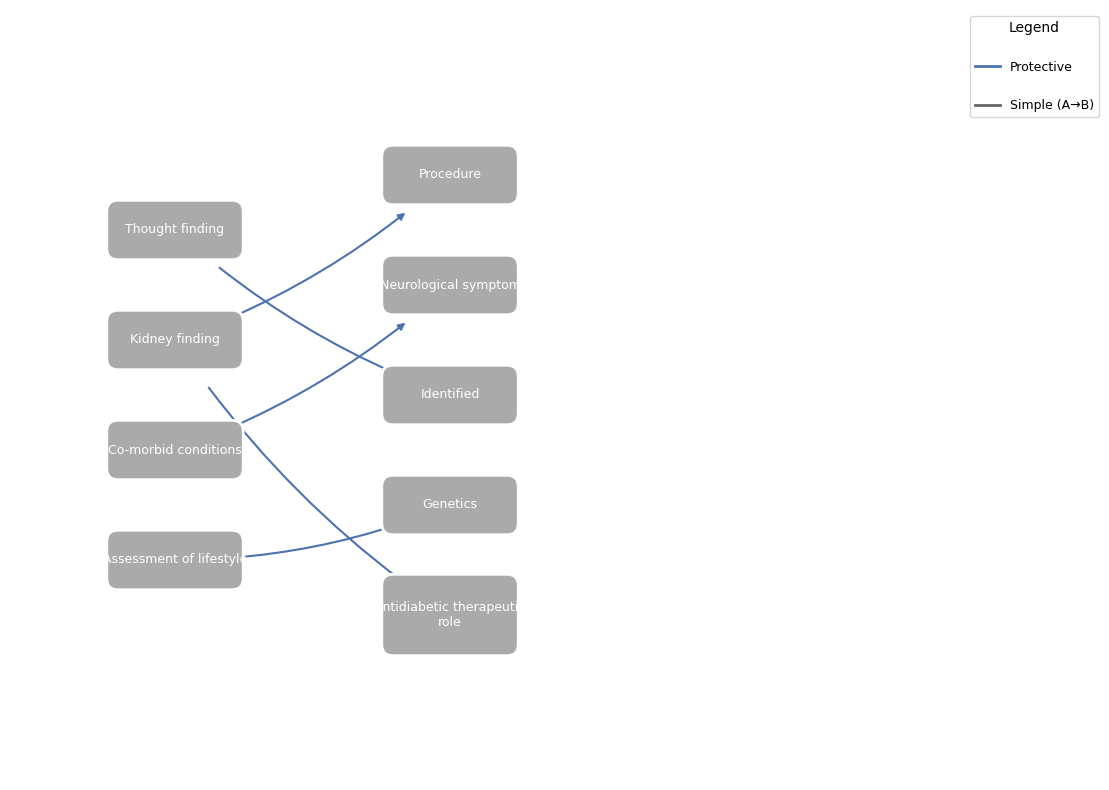

In [14]:
graph = soap_note.extract_causal_graph()                                                                                                                      
print(graph.summary())                                                                                                                                        

fig=graph.plot(
    interactive=False,
    # save_path="causal_graph.png"
)    
fig                                                                                                        
                                                               

## 6. Batch Processing

Generate SOAP notes for multiple patients.

In [21]:
# Generate SOAP notes for multiple patients
soap_notes = []

for i, patient in enumerate(dataset[:3]):  # First 3 patients
    print(f"\nProcessing patient {i+1}/3: {patient.name or patient.patient_id[:8]}...")
    
    note = generator.generate(patient, include_imaging=True)
    soap_notes.append(note)
    
    print(f"  ✓ Generated ({note.time_periods_summarized} time periods, {note.images_analyzed} images)")

print("\n" + "=" * 60)
print(f"Generated {len(soap_notes)} SOAP notes")


Processing patient 1/3: Alica Feeney...
  BioMCP enrichment: 0.00s
Generating SOAP note for: Alica Feeney
  Input: ~1,766 tokens
  Processing: DIRECT


Generating SOAP note:   0%|          | 0/3 [00:00<?, ?it/s, Analyzing patient data]Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


KeyboardInterrupt: 

In [ ]:
# View summaries for all patients
print("Patient Summaries")
print("=" * 60)

for note in soap_notes:
    print(f"\n{note.patient_name or note.patient_id[:8]}:")
    print(f"  {note.summary[:200]}..." if len(note.summary) > 200 else f"  {note.summary}")

## 7. Simple One-Line API

For quick generation, use the convenience function:

In [ ]:
# One-line SOAP note generation
from synthlab.soap import generate_soap_note

quick_note = generate_soap_note(dataset[0])
print(quick_note.summary)

## Summary

```python
import synthlab as sl
from synthlab.soap import SOAPNoteGenerator, generate_soap_note

# Load patient data
dataset = sl.load_multimodal_dataset(max_patients=10)
patient = dataset[0]

# Quick generation
soap_note = generate_soap_note(patient)
print(soap_note)

# Or with more control
generator = SOAPNoteGenerator(
    model_id="google/medgemma-1.5-4b-it",
    chunk_period_years=5,
)
soap_note = generator.generate(patient, include_imaging=True)

# Access structured output
print(soap_note.subjective)
print(soap_note.assessment)
print(soap_note.future_considerations)

# Export
json_output = soap_note.to_json()
```

### Key Features

- **Hierarchical summarization** handles decades of patient history
- **Multimodal** includes DICOM imaging when available
- **Future-oriented** identifies potential health risks
- **Structured output** with SOAP sections + executive summary
- **Export-ready** JSON output for EHR integration